In [1]:
# Parameters
BATCH_MODE = "true"
SEED = 42
print(f"Parametres : BATCH_MODE={BATCH_MODE}, SEED={SEED}")

Parametres : BATCH_MODE=true, SEED=42


# App-23 - Factorio Belt Balancer (CP-SAT borne)

**Navigation** : [<< App-22 EdgeColoring Tutte](../CSP/App-22-EdgeColoring-Tutte.ipynb) | [Index](../README.md) | [App-26 Covering Arrays >>](../CSP/App-26-CoveringArrays-Guarantee-Audit.ipynb)

## Belt balancer Factorio : MIP continu vs CP-SAT discret sur cas borne

Ce notebook modelise un probleme de flux inspire de Factorio : repartir `N` injections de capacite `P` entre `N` sorties, chaque source devant contribuer a toutes les sorties. Les deux bras utilisent la meme topologie `W=N, H=N+1` : la ligne supplementaire est une lane de routage interne, sans source ni sortie additionnelle.

1. **MIP continu** (OR-Tools SCIP) : les flux sont reels et representent exactement `P/N`.
2. **CP-SAT entier** : les flux sont entiers et approchent `P/N` par une bande `{floor(P/N), ceil(P/N)}`.

Une face physique transporte au total au plus `P`, **toutes sources confondues**. Deux organes verifient les resultats : un audit direct du tenseur de flux produit et un LP multicommodite reconstruit uniquement depuis la grille.

La source canonique est l'article de Gianluca Venturini (2024), *Learning Solver Design: Automating Factorio Balancers*, archive dans la bibliographie partagee. La formulation ci-dessous est une reimplementation originale avec un mixer redistributif conservatif a une cellule.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. modeliser un flux multicommodite avec capacite physique partagee ;
2. comparer domaines continu et entier sur une formulation commune ;
3. distinguer audit du routage produit et validation topologique independante ;
4. interpreter honnetement `OPTIMAL`, `FEASIBLE`, `INFEASIBLE` et `UNKNOWN`.

### Prerequis

- CSP-3 (Advanced) : CP-SAT, MIP
- Python : numpy, matplotlib

### Duree estimee : 40 minutes

***

## 1. Le probleme du belt balancer (~6 min)

### Contexte Factorio

Dans Factorio, les tapis roulants transportent des items entre batiments. Un tapis a un **debit maximum** (1 item/case), donc pour transporter plus, on **parallelise** les lanes. Quand on a N entrees en parallele, elles peuvent se **desynchroniser** : un miner lent peut ralentir une lane entiere.

Un **belt balancer** est un circuit qui prend N entrees en parallele et les redistribue sur N sorties de telle sorte que **chaque entree apparaisse en parts egales dans chaque sortie**.

### Composants elementaires (perimetre borne)

Pour un cas **pedagogiquement borne**, on limite les composants a :

| Composant | Cellules | Effet |
|-----------|----------|-------|
| **Belt** (tapis droit) | 1 | Transporte le flux dans une direction, conserve la quantite |
| **Mixer** (brassage conservatif) | 1 | Prend 2 flux en entree et les REDISTRIBUE sur 2 sorties : la somme des entrees se retrouve exactement sur la somme des sorties |

Le mixer ne "croise" pas les canaux : il garantit seulement la **conservation en somme**. La repartition entre ses deux sorties est un degre de liberte que le solveur exploite. C'est une divergence assumee et documentee vis-a-vis du splitter 2-cellules de Venturini (voir section 9).

Les **underground belts** (tapis souterrains, distance > 1) sont exclus pour eviter l'explosion combinatoire documentee par Venturini.

### Variables et contraintes (formulation adaptee de Venturini)

On definit une **grille H x W** de cellules, chaque cellule portant au plus un composant. On note `N = min(H, W)` le nombre de sources (bord gauche) et de sorties (bord droit). Chaque face saturee porte `P` unites de flux. On note :

- `comp[i][j][k]` : binaire, cellule `(i,j)` porte le composant `k`
- `flow[i][j][d][s]` : debit de la source `s` sur la **face `d`** de la cellule `(i,j)`

**Contraintes** :
1. **Un seul composant par cellule** : `somme_k comp[i][j][k] <= 1`
2. **Conservation de flux** par cellule et par source (belt : egalite 1-1 ; mixer : egalite en SOMME)
3. **Faces coherentes** : une face ne porte du flux que si le composant la cite ; une face partagee relie exactement un emetteur et un recepteur
4. **Throughput-unlimited** : chaque source `s` livre sa part `P/N` a chaque sortie

### Imports et verification de l'environnement

In [2]:
import sys
import time
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ortools.linear_solver import pywraplp
from ortools.sat.python import cp_model

print(f"Python         : {sys.version.split()[0]}")
print(f"NumPy          : {np.__version__}")
print(f"Matplotlib     : {__import__('matplotlib').__version__}")
print(f"OR-Tools SCIP  : {pywraplp.Solver.CreateSolver('SCIP') is not None}")
print(f"OR-Tools CP-SAT: OK")

# Seed pour reproductibilite
np.random.seed(42)

# Constantes globales
SEED = 42
# Echelle commune aux deux moteurs : une face saturee porte P_FULL unites.
# Le MIP resout ces unites en variables reelles, CP-SAT en variables
# entieres -- la difference entre les deux bras est le DOMAINE, pas l'echelle.
P_FULL = 8

Python         : 3.13.3
NumPy          : 2.4.3
Matplotlib     : 3.10.3
OR-Tools SCIP  : True
OR-Tools CP-SAT: OK


***

## 2. Representation du probleme (~5 min)

### Conventions

- Coordonnees : `(row, col)` = `(i, j)`, ligne en premier
- Directions : `N=0` (haut), `S=1` (bas), `E=2` (droite), `W=3` (gauche)
- Sources sur le bord **gauche** (`col=0`), une par ligne : `N = min(H, W)`
- Sorties sur le bord **droit** (`col=W-1`), une par ligne
- La source `s` injecte `P` unites sur la face ouest de `(s, 0)` ; la sortie `o` lit la face est de `(o, W-1)`

### Types de composants (9 possibilites par cellule)

| k | Nom | Faces ENTREE | Faces SORTIE |
|---|-----|--------------|--------------|
| 0 | empty | -- | -- |
| 1 | belt-N | S | N |
| 2 | belt-S | N | S |
| 3 | belt-E | W | E |
| 4 | belt-W | E | W |
| 5 | mixer-NE | S, W | N, E |
| 6 | mixer-NW | S, E | N, W |
| 7 | mixer-SE | N, W | S, E |
| 8 | mixer-SW | N, E | S, W |

Le mixer est nomme par ses **2 sorties**. Un belt conserve exactement (l'unique entree egale l'unique sortie) ; un mixer **redistribue** : la somme de ses 2 entrees egale la somme de ses 2 sorties, la repartition interne etant libre. Pour chaque composant, `IN` et `OUT` sont disjoints -- une face ne peut pas etre a la fois entree et sortie.

In [3]:
# Convention : N=0 (haut), S=1 (bas), E=2 (droite), W=3 (gauche)
DIRS = ['N', 'S', 'E', 'W']
OPP = {0: 1, 1: 0, 2: 3, 3: 2}
DELTA = {0: (-1, 0), 1: (1, 0), 2: (0, 1), 3: (0, -1)}

# Types de composants (le mixer est nomme par ses 2 sorties)
COMP_NAMES = ['empty', 'belt-N', 'belt-S', 'belt-E', 'belt-W',
              'mixer-NE', 'mixer-NW', 'mixer-SE', 'mixer-SW']

# Semantique conservative "mixer redistributif" : chaque composant declare
# ses faces ENTREE (COMP_IN) et ses faces SORTIE (COMP_OUT).
#   Belt  : 1 entree, 1 sortie, conservation exacte (egalite des 2 debits).
#   Mixer : 2 entrees, 2 sorties, REDISTRIBUTION conservative -- somme des
#           entrees == somme des sorties. Le mixer ne croise PAS les canaux :
#           la repartition entre les 2 sorties est un degre de liberte.
# ATTENTION : cette liberte est une RELAXATION du splitter Factorio, qui
#           partage son debit total en parts EGALES. Le modele livre donc
#           une borne superieure de faisabilite ; la contrainte C9
#           (split_equitable, section 7) durcit ce point et mesure l'ecart.
# IN et OUT sont disjoints pour chaque composant (une face n'est jamais
# les deux a la fois).
COMP_IN = {
    1: {1},      # belt-N : entree S
    2: {0},      # belt-S : entree N
    3: {3},      # belt-E : entree W
    4: {2},      # belt-W : entree E
    5: {1, 3},   # mixer-NE : entrees S et W
    6: {1, 2},   # mixer-NW : entrees S et E
    7: {0, 3},   # mixer-SE : entrees N et W
    8: {0, 2},   # mixer-SW : entrees N et E
}
COMP_OUT = {
    1: {0},      # belt-N : sortie N
    2: {1},      # belt-S : sortie S
    3: {2},      # belt-E : sortie E
    4: {3},      # belt-W : sortie W
    5: {0, 2},   # mixer-NE : sorties N et E
    6: {0, 3},   # mixer-NW : sorties N et W
    7: {1, 2},   # mixer-SE : sorties S et E
    8: {1, 3},   # mixer-SW : sorties S et W
}

# Composants acceptant une INJECTION depuis le bord ouest (face W en entree)
SRC_KINDS = tuple(k for k in range(1, 9) if 3 in COMP_IN[k])
# Composants pouvant EVACUER vers le bord est (face E en sortie)
OUT_KINDS = tuple(k for k in range(1, 9) if 2 in COMP_OUT[k])

# Invariant structurel : une face n'est jamais entree ET sortie du meme composant
for _k in range(1, 9):
    assert not (COMP_IN[_k] & COMP_OUT[_k]), f"IN/OUT non disjoints pour k={_k}"

print(f"Composants : {len(COMP_NAMES)} (1 vide + 4 belts + 4 mixers)")
print(f"Mixers redistributifs : 2 entrees / 2 sorties, conservation en somme")
print(f"SRC_KINDS (acceptent l'injection W) : {SRC_KINDS}")
print(f"OUT_KINDS (evacuent vers E)         : {OUT_KINDS}")

Composants : 9 (1 vide + 4 belts + 4 mixers)
Mixers redistributifs : 2 entrees / 2 sorties, conservation en somme
SRC_KINDS (acceptent l'injection W) : (3, 5, 7)
OUT_KINDS (evacuent vers E)         : (3, 5, 7)


### Visualisation d'une solution

Caracteres Unicode pour afficher la grille, dans l'esprit du test d'inspection de Venturini (page 4 du PDF).

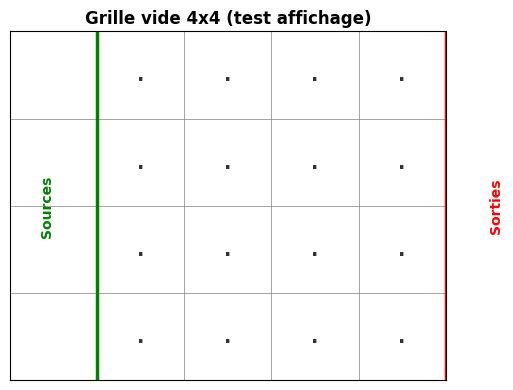

Fonction d'affichage OK.


In [4]:
SYM = {
    0: '.', 1: '^', 2: 'v', 3: '>', 4: '<',
    5: '+', 6: '+', 7: '+', 8: '+',
}

def display_balancer(grid, title="Belt balancer", figsize=None):
    """Affiche une grille de balancer comme matrice de symboles colores."""
    h, w = grid.shape
    if figsize is None:
        figsize = (w * 0.8 + 2, h * 0.8 + 2)
    fig, ax = plt.subplots(figsize=figsize)

    cmap = mcolors.ListedColormap(['#FFFFFF', '#E3F2FD', '#E3F2FD',
                                    '#E3F2FD', '#E3F2FD',
                                    '#FFE0B2', '#FFE0B2', '#FFE0B2', '#FFE0B2'])
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=8, aspect='equal')

    for i in range(h):
        for j in range(w):
            ax.text(j, i, SYM[grid[i, j]], ha='center', va='center',
                    fontsize=14, fontweight='bold', color='#333')

    for i in range(h + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5)
    for j in range(w + 1):
        ax.axvline(j - 0.5, color='gray', linewidth=0.5)

    ax.axvline(-0.5, color='green', linewidth=2.5)
    ax.axvline(w - 0.5, color='red', linewidth=2.5)
    ax.text(-1.0, h / 2 - 0.5, 'Sources', ha='right', va='center',
            fontsize=10, color='green', fontweight='bold', rotation=90)
    ax.text(w, h / 2 - 0.5, 'Sorties', ha='left', va='center',
            fontsize=10, color='red', fontweight='bold', rotation=90)

    ax.set_xlim(-1.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig


test_grid = np.zeros((4, 4), dtype=int)
display_balancer(test_grid, title="Grille vide 4x4 (test affichage)")
plt.show()
print("Fonction d'affichage OK.")


***

## 3. Baseline constructive : belts droits seulement (~4 min)

### Le baseline trivial (sans mixer)

Le balancer trivial est compose uniquement de **belts droits** qui transportent chaque entree vers la sortie de meme index. Ses quatre composants occupent toute la grille 2x2, mais ils ne brassent rien : chaque ligne reste isolee des autres. Le validateur de la section 7 le rejettera.

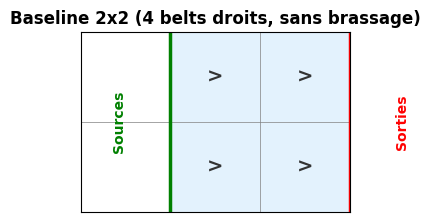

Baseline trivial : input i -> output i, aucun mix.


In [5]:
def constructive_baseline(width, height):
    """Grille de belts droits uniquement : input i -> output i direct."""
    return np.full((height, width), 3, dtype=int)  # tout belt-E


baseline_2x2 = constructive_baseline(2, 2)
display_balancer(baseline_2x2, title="Baseline 2x2 (4 belts droits, sans brassage)")
plt.show()
print("Baseline trivial : input i -> output i, aucun mix.")

### Baseline non-trivial : au moins un mixer

Pour verifier la propriete *throughput-unlimited*, il faut du brassage vertical entre lignes. Le baseline 3x3 ci-dessous pose un mixer central isole au milieu de belts-E : aucun voisin n'expose de face verticale compatible. Le LP multicommodite de la section 7 le rejettera, car aucune redistribution simultanee n'est possible.

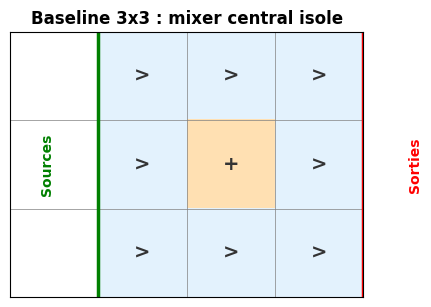

Baseline 3x3 : le mixer isole ne peut pas redistribuer entre lignes.
Le LP multicommodite de la section 7 testera cette prediction.


In [6]:
def constructive_with_mixer_3x3():
    """Baseline 3x3 avec un mixer central volontairement insuffisant."""
    grid = np.array([
        [3, 3, 3],
        [3, 5, 3],
        [3, 3, 3],
    ], dtype=int)
    return grid


baseline_mixer = constructive_with_mixer_3x3()
display_balancer(baseline_mixer, title="Baseline 3x3 : mixer central isole")
plt.show()
print("Baseline 3x3 : le mixer isole ne peut pas redistribuer entre lignes.")
print("Le LP multicommodite de la section 7 testera cette prediction.")

***

## 4. Bras MIP : flux continu (~8 min)

### Unites et variables

Les deux moteurs resolvent le meme modele logique sur la meme echelle. Une face saturee porte au total `P = 8` unites :

- `comp[i][j][k]` choisit le composant de la cellule ;
- `flow[i][j][d][s]` mesure la contribution de la source `s` sur une face ;
- le debit physique d'une face est `sum_s flow[i][j][d][s]`, borne par `P`.

### Contraintes C1..C8

1. **C1** Au plus un composant par cellule.
2. **C2** Au moins `min_mixers` mixers.
3. **C3** Une face inactive porte zero ; une face active porte au total au plus `P`, toutes sources confondues.
4. **C4** Conservation par cellule et par source.
5. **C5** Les deux cellules voisines partagent la meme valeur de face.
6. **C5b** Une face active relie un emetteur et un recepteur.
7. **C6** Les `N` premieres lignes portent sources et sorties ; une ligne supplementaire sert uniquement au routage interne.
8. **C7** Les composants de bord sont compatibles avec injections et sorties.
9. **C8** Chaque source livre `P/N` a chaque sortie en continu.

**Objectif** : minimiser le nombre total de composants. Le statut `FEASIBLE` prouve une solution conforme mais pas son optimalite ; `UNKNOWN` ne prouve ni faisabilite ni infaisabilite.

In [7]:
def solve_mip_balancer(width, height, time_limit=30.0, P=8, min_mixers=2):
    """Resout le balancer en MIP continu (SCIP) avec capacite physique partagee.

    Retourne le statut, la grille, la matrice livree et le tenseur de flux afin
    qu'un audit distinct puisse verifier le routage effectivement produit.
    """
    W, H = width, height
    N = min(H, W)
    solver = pywraplp.Solver.CreateSolver('SCIP')
    if solver is None:
        raise RuntimeError("SCIP non disponible dans OR-Tools")
    solver.SetTimeLimit(int(time_limit * 1000))
    NK = len(COMP_NAMES)

    def _kinds_using(d):
        return [k for k in range(1, NK) if d in COMP_IN[k] or d in COMP_OUT[k]]

    def _kinds_with(d, role):
        table = COMP_IN if role == 'in' else COMP_OUT
        return [k for k in range(1, NK) if d in table[k]]

    comp = {(i, j, k): solver.IntVar(0, 1, f'c_{i}_{j}_{k}')
            for i in range(H) for j in range(W) for k in range(1, NK)}
    flow = {(i, j, d, s): solver.NumVar(0.0, float(P), f'f_{i}_{j}_{d}_{s}')
            for i in range(H) for j in range(W) for d in range(4) for s in range(N)}

    # C1 : au plus un composant par cellule.
    for i in range(H):
        for j in range(W):
            solver.Add(sum(comp[i, j, k] for k in range(1, NK)) <= 1)

    # C2 : au moins min_mixers mixers.
    mixer_kinds = (5, 6, 7, 8)
    solver.Add(sum(comp[i, j, k] for i in range(H) for j in range(W)
                   for k in mixer_kinds) >= min_mixers)

    # C3 : face active seulement si le composant la cite, avec capacite
    # PHYSIQUE totale P partagee entre toutes les sources.
    for i in range(H):
        for j in range(W):
            for d in range(4):
                allowed = sum(comp[i, j, k] for k in _kinds_using(d))
                for s in range(N):
                    solver.Add(flow[i, j, d, s] <= P * allowed)
                solver.Add(
                    sum(flow[i, j, d, s] for s in range(N)) <= P * allowed
                )

    # C4 : conservation par cellule et par source.
    for i in range(H):
        for j in range(W):
            for k in range(1, NK):
                for s in range(N):
                    incoming = sum(flow[i, j, d, s] for d in COMP_IN[k])
                    outgoing = sum(flow[i, j, d, s] for d in COMP_OUT[k])
                    solver.Add(incoming - outgoing <= 2 * P * (1 - comp[i, j, k]))
                    solver.Add(outgoing - incoming <= 2 * P * (1 - comp[i, j, k]))

    # C5 : couplage physique des faces partagees.
    for i in range(H):
        for j in range(W - 1):
            for s in range(N):
                solver.Add(flow[i, j, 2, s] == flow[i, j + 1, 3, s])
    for i in range(H - 1):
        for j in range(W):
            for s in range(N):
                solver.Add(flow[i + 1, j, 0, s] == flow[i, j, 1, s])

    # C5b : exactement un emetteur et un recepteur sur une face active.
    for i in range(H):
        for j in range(W - 1):
            e_out = sum(comp[i, j, k] for k in _kinds_with(2, 'out'))
            e_in = sum(comp[i, j, k] for k in _kinds_with(2, 'in'))
            w_out = sum(comp[i, j + 1, k] for k in _kinds_with(3, 'out'))
            w_in = sum(comp[i, j + 1, k] for k in _kinds_with(3, 'in'))
            for s in range(N):
                solver.Add(flow[i, j, 2, s] <= P * (2 - e_out - w_out))
                solver.Add(flow[i, j, 2, s] <= P * (2 - e_in - w_in))
    for i in range(H - 1):
        for j in range(W):
            s_out = sum(comp[i, j, k] for k in _kinds_with(1, 'out'))
            s_in = sum(comp[i, j, k] for k in _kinds_with(1, 'in'))
            n_out = sum(comp[i + 1, j, k] for k in _kinds_with(0, 'out'))
            n_in = sum(comp[i + 1, j, k] for k in _kinds_with(0, 'in'))
            for s in range(N):
                solver.Add(flow[i, j, 1, s] <= P * (2 - s_out - n_out))
                solver.Add(flow[i, j, 1, s] <= P * (2 - s_in - n_in))

    # C6 : bords, N injections et N sorties ; les lignes supplementaires sont
    # des lanes internes, fermees a gauche et a droite.
    for j in range(W):
        for s in range(N):
            solver.Add(flow[0, j, 0, s] == 0.0)
            solver.Add(flow[H - 1, j, 1, s] == 0.0)
    for i in range(H):
        for s in range(N):
            if i < N:
                solver.Add(flow[i, 0, 3, s] == (float(P) if s == i else 0.0))
            else:
                solver.Add(flow[i, 0, 3, s] == 0.0)
            if i >= N:
                solver.Add(flow[i, W - 1, 2, s] == 0.0)

    # C7 : ancres aux N injections et N sorties.
    for s in range(N):
        solver.Add(sum(comp[s, 0, k] for k in SRC_KINDS) == 1)
    for o in range(N):
        solver.Add(sum(comp[o, W - 1, k] for k in OUT_KINDS) == 1)

    # C8 : chaque source livre exactement P/N a chaque sortie. Les injections
    # exactes et la conservation rendent la borne inferieure exacte globalement.
    share = P / N
    for s in range(N):
        for o in range(N):
            solver.Add(flow[o, W - 1, 2, s] >= share)

    solver.Minimize(sum(comp[i, j, k] for i in range(H) for j in range(W)
                        for k in range(1, NK)))
    start = time.time()
    status = solver.Solve()
    elapsed = time.time() - start
    status_name = {0: 'OPTIMAL', 1: 'FEASIBLE', 2: 'INFEASIBLE', 3: 'UNBOUNDED',
                   4: 'ABNORMAL', 5: 'NOT_SOLVED'}.get(status, 'UNKNOWN')
    out = {'status': status_name, 'time_s': elapsed, 'grid': None,
           'objective': None, 'share': share, 'share_matrix': None,
           'share_error': None, 'reached': 0, 'flow_tensor': None,
           'engine': 'MIP', 'P': P}
    if status not in (0, 1):
        return out

    grid = np.zeros((H, W), dtype=int)
    for i in range(H):
        for j in range(W):
            for k in range(1, NK):
                if comp[i, j, k].solution_value() > 0.5:
                    grid[i, j] = k
                    break
    tensor = np.array([[[[flow[i, j, d, s].solution_value()
                          for s in range(N)] for d in range(4)]
                        for j in range(W)] for i in range(H)])
    matrix = np.array([[tensor[o, W - 1, 2, s] for o in range(N)]
                       for s in range(N)])
    out.update({'grid': grid, 'objective': solver.Objective().Value(),
                'share_matrix': matrix,
                'share_error': float(np.abs(matrix - share).max()),
                'reached': int(np.sum(matrix > 1e-9)),
                'flow_tensor': tensor})
    return out


print("Fonction MIP compilee : capacite totale P partagee par face.")

Fonction MIP compilee : capacite totale P partagee par face.


### Test MIP : N sources/sorties sur une grille N x (N+1)

Test MIP - N sources/sorties sur grilles N x (N+1), P = 8

Resolution MIP N=2, grille 2x3...
  Statut    : OPTIMAL
  Temps     : 37.3 ms
  Objectif  : 6
  Err P/N   : 0.00e+00


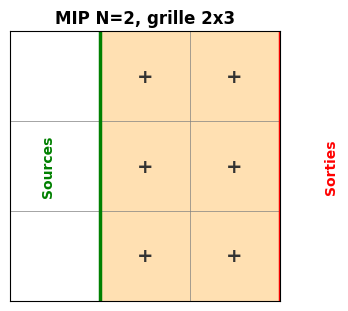


Resolution MIP N=3, grille 3x4...


  Statut    : OPTIMAL
  Temps     : 892.3 ms
  Objectif  : 11
  Err P/N   : 4.44e-16


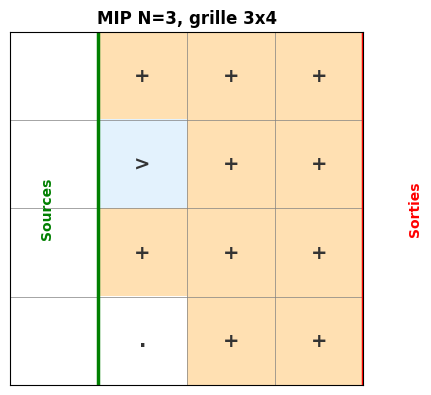


Resolution MIP N=4, grille 4x5...


  Statut    : FEASIBLE
  Temps     : 34478.7 ms
  Objectif  : 18
  Err P/N   : 0.00e+00


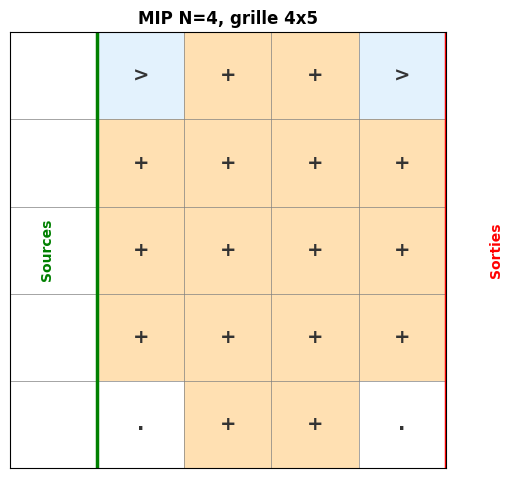

In [8]:
print("Test MIP - N sources/sorties sur grilles N x (N+1), P = 8")
print("=" * 68)

CASES = [(2, 3), (3, 4), (4, 5)]  # (W=N, H=N+1)
mip_results_summary = {}
for W, H in CASES:
    n = W
    print(f"\nResolution MIP N={n}, grille {W}x{H}...")
    result = solve_mip_balancer(W, H, time_limit=35.0, P=P_FULL)
    mip_results_summary[(W, H)] = result
    objective = (f"{result['objective']:.0f}"
                 if result['objective'] is not None else "N/A")
    error = (f"{result['share_error']:.2e}"
             if result['share_error'] is not None else "N/A")
    print(f"  Statut    : {result['status']}")
    print(f"  Temps     : {result['time_s']*1000:.1f} ms")
    print(f"  Objectif  : {objective}")
    print(f"  Err P/N   : {error}")
    if result['grid'] is not None:
        display_balancer(result['grid'], title=f"MIP N={n}, grille {W}x{H}")
        plt.show()

print("=" * 68)

***

## 5. Bras CP-SAT : flux entier (~8 min)

### Discretisation

Le modele logique est **le meme** que celui de la section 4 (C1..C8, y compris C5b), sur la **meme echelle** `P = 8`. La seule difference :

- `comp[i][j][k]` : BoolVar
- `flow[i][j][d][s]` : IntVar dans `[0, P]` -- le flux vit dans les **entiers**

La conservation C4 s'ecrit avec `Add(...).OnlyEnforceIf(comp[i, j, k])` (pas besoin de big-M), et C5b garde sa forme lineaire exacte.

### C8 en nombres entiers : deux lectures

`P/N = 8/3` n'est pas un entier. La contrainte C8 peut se lire de deux facons :

- **mode `band`** : chaque livraison appartient a la bande `[P//N, ceil(P/N)]` = `[2, 3]` -- la quantification honnete a la resolution 1/N, la plus proche possible de 8/3 en unites entieres
- **mode `ceil`** : chaque livraison vaut au moins `ceil(P/N)` = 3 -- exiger "au moins la part arrondie au-dessus", ce qui est trop demander quand N ne divise pas P

### Determinisme

Le solveur tourne avec `num_workers = 1` et `random_seed = SEED` : deux executions donnent exactement la meme solution (grille et matrice de debits), ce qui rend les sorties de ce notebook reproductibles.

In [9]:
def solve_cpsat_balancer(width, height, time_limit=30.0, P=8, min_mixers=2,
                         mode='band', split_equitable=False):
    """Resout le balancer en CP-SAT entier avec capacite physique partagee.

    split_equitable=True active la contrainte C9 : chaque mixer distribue
    la SOMME de ses sorties a parts egales entre ses deux faces de sortie,
    comme un splitter Factorio reel (les flux entiers imposent alors un
    total pair par mixer).
    """
    W, H = width, height
    N = min(H, W)
    model = cp_model.CpModel()
    NK = len(COMP_NAMES)

    def _kinds_using(d):
        return [k for k in range(1, NK) if d in COMP_IN[k] or d in COMP_OUT[k]]

    def _kinds_with(d, role):
        table = COMP_IN if role == 'in' else COMP_OUT
        return [k for k in range(1, NK) if d in table[k]]

    comp = {(i, j, k): model.NewBoolVar(f'c_{i}_{j}_{k}')
            for i in range(H) for j in range(W) for k in range(1, NK)}
    flow = {(i, j, d, s): model.NewIntVar(0, P, f'f_{i}_{j}_{d}_{s}')
            for i in range(H) for j in range(W) for d in range(4) for s in range(N)}

    # C1 : au plus un composant par cellule.
    for i in range(H):
        for j in range(W):
            model.Add(sum(comp[i, j, k] for k in range(1, NK)) <= 1)

    # C2 : au moins min_mixers mixers.
    mixer_kinds = (5, 6, 7, 8)
    model.Add(sum(comp[i, j, k] for i in range(H) for j in range(W)
                  for k in mixer_kinds) >= min_mixers)

    # C3 : face active seulement si le composant la cite, avec capacite
    # PHYSIQUE totale P partagee entre toutes les sources.
    for i in range(H):
        for j in range(W):
            for d in range(4):
                allowed = sum(comp[i, j, k] for k in _kinds_using(d))
                for s in range(N):
                    model.Add(flow[i, j, d, s] <= P * allowed)
                model.Add(
                    sum(flow[i, j, d, s] for s in range(N)) <= P * allowed
                )

    # C4 : conservation par cellule et par source.
    for i in range(H):
        for j in range(W):
            for k in range(1, NK):
                for s in range(N):
                    incoming = sum(flow[i, j, d, s] for d in COMP_IN[k])
                    outgoing = sum(flow[i, j, d, s] for d in COMP_OUT[k])
                    model.Add(incoming == outgoing).OnlyEnforceIf(comp[i, j, k])

    # C5 : couplage physique des faces partagees.
    for i in range(H):
        for j in range(W - 1):
            for s in range(N):
                model.Add(flow[i, j, 2, s] == flow[i, j + 1, 3, s])
    for i in range(H - 1):
        for j in range(W):
            for s in range(N):
                model.Add(flow[i + 1, j, 0, s] == flow[i, j, 1, s])

    # C5b : exactement un emetteur et un recepteur sur une face active.
    for i in range(H):
        for j in range(W - 1):
            e_out = sum(comp[i, j, k] for k in _kinds_with(2, 'out'))
            e_in = sum(comp[i, j, k] for k in _kinds_with(2, 'in'))
            w_out = sum(comp[i, j + 1, k] for k in _kinds_with(3, 'out'))
            w_in = sum(comp[i, j + 1, k] for k in _kinds_with(3, 'in'))
            for s in range(N):
                model.Add(flow[i, j, 2, s] <= P * (2 - e_out - w_out))
                model.Add(flow[i, j, 2, s] <= P * (2 - e_in - w_in))
    for i in range(H - 1):
        for j in range(W):
            s_out = sum(comp[i, j, k] for k in _kinds_with(1, 'out'))
            s_in = sum(comp[i, j, k] for k in _kinds_with(1, 'in'))
            n_out = sum(comp[i + 1, j, k] for k in _kinds_with(0, 'out'))
            n_in = sum(comp[i + 1, j, k] for k in _kinds_with(0, 'in'))
            for s in range(N):
                model.Add(flow[i, j, 1, s] <= P * (2 - s_out - n_out))
                model.Add(flow[i, j, 1, s] <= P * (2 - s_in - n_in))

    # C6 : bords, N injections et N sorties ; les lignes supplementaires sont
    # des lanes internes, fermees a gauche et a droite.
    for j in range(W):
        for s in range(N):
            model.Add(flow[0, j, 0, s] == 0)
            model.Add(flow[H - 1, j, 1, s] == 0)
    for i in range(H):
        for s in range(N):
            if i < N:
                model.Add(flow[i, 0, 3, s] == (P if s == i else 0))
            else:
                model.Add(flow[i, 0, 3, s] == 0)
            if i >= N:
                model.Add(flow[i, W - 1, 2, s] == 0)

    # C7 : ancres aux N injections et N sorties.
    for s in range(N):
        model.Add(sum(comp[s, 0, k] for k in SRC_KINDS) == 1)
    for o in range(N):
        model.Add(sum(comp[o, W - 1, k] for k in OUT_KINDS) == 1)

    # C8 : deux lectures entieres de P/N.
    share = P / N
    share_lo = P // N
    share_hi = -(-P // N)
    for s in range(N):
        for o in range(N):
            if mode == 'ceil':
                model.Add(flow[o, W - 1, 2, s] >= share_hi)
            else:
                model.Add(flow[o, W - 1, 2, s] >= share_lo)
                model.Add(flow[o, W - 1, 2, s] <= share_hi)

    # C9 (optionnelle, split_equitable) : chaque mixer pose redistribue a
    # parts EGALES entre ses deux sorties, comme un splitter Factorio reel.
    # Les flux etant entiers, ceci impose de fait un total PAIR par mixer.
    if split_equitable:
        for i in range(H):
            for j in range(W):
                for k in mixer_kinds:
                    d1, d2 = sorted(COMP_OUT[k])
                    tot1 = sum(flow[i, j, d1, s] for s in range(N))
                    tot2 = sum(flow[i, j, d2, s] for s in range(N))
                    model.Add(tot1 == tot2).OnlyEnforceIf(comp[i, j, k])

    model.Minimize(sum(comp[i, j, k] for i in range(H) for j in range(W)
                       for k in range(1, NK)))
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_workers = 1
    solver.parameters.random_seed = SEED
    start = time.time()
    status = solver.Solve(model)
    elapsed = time.time() - start
    out = {'status': solver.StatusName(status), 'time_s': elapsed, 'grid': None,
           'objective': None, 'branches': solver.NumBranches(),
           'conflicts': solver.NumConflicts(), 'share': share,
           'share_lo': share_lo, 'share_hi': share_hi, 'share_matrix': None,
           'share_error': None, 'reached': 0, 'flow_tensor': None,
           'engine': 'CP-SAT', 'P': P, 'mode': mode,
           'split_equitable': split_equitable}
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return out

    grid = np.zeros((H, W), dtype=int)
    for i in range(H):
        for j in range(W):
            for k in range(1, NK):
                if solver.Value(comp[i, j, k]):
                    grid[i, j] = k
                    break
    tensor = np.array([[[[solver.Value(flow[i, j, d, s])
                          for s in range(N)] for d in range(4)]
                        for j in range(W)] for i in range(H)], dtype=float)
    matrix = np.array([[tensor[o, W - 1, 2, s] for o in range(N)]
                       for s in range(N)], dtype=float)
    out.update({'grid': grid, 'objective': solver.ObjectiveValue(),
                'share_matrix': matrix,
                'share_error': float(np.abs(matrix - share).max()),
                'reached': int(np.sum(matrix > 0)),
                'flow_tensor': tensor})
    return out


print("Fonction CP-SAT compilee : capacite totale P partagee par face,")
print("contrainte C9 optionnelle (split_equitable).")

Fonction CP-SAT compilee : capacite totale P partagee par face,
contrainte C9 optionnelle (split_equitable).


### Test CP-SAT : bande et ceil sur les memes grilles, puis controle divisible

In [10]:
cpsat_results = {}
cpsat_ceil_results = {}
square_controls = {}

print("CP-SAT bande - N sources/sorties sur grilles N x (N+1), P = 8")
print("=" * 92)
print(f"{'N / grille':<13} {'Statut':<10} {'Temps (ms)':<11} {'Branches':<10} "
      f"{'[lo, hi]':<10} {'Err max':<10} {'Atteints'}")
print("-" * 92)
for W, H in CASES:
    n = W
    result = solve_cpsat_balancer(W, H, time_limit=15.0, P=P_FULL, mode='band')
    cpsat_results[(W, H)] = result
    error = (f"{result['share_error']:.4f}"
             if result['share_error'] is not None else "N/A")
    print(f"{n} / {W}x{H:<7} {result['status']:<10} "
          f"{result['time_s']*1000:<11.1f} {result['branches']:<10} "
          f"[{result['share_lo']}, {result['share_hi']}]   "
          f"{error:<10} {result['reached']}/{n*n}")
print("=" * 92)

print("\nControle topologique : grilles carrees N x N avec capacite partagee")
print("=" * 64)
for n in (2, 3, 4):
    result = solve_cpsat_balancer(n, n, time_limit=5.0, P=P_FULL, mode='band')
    square_controls[n] = result
    print(f"  N={n}, {n}x{n} : {result['status']}")
print("=" * 64)

print("\nCP-SAT ceil sur les memes grilles N x (N+1)")
print("=" * 64)
for W, H in CASES:
    n = W
    result = solve_cpsat_balancer(W, H, time_limit=15.0, P=P_FULL, mode='ceil')
    cpsat_ceil_results[(W, H)] = result
    error = (f"err={result['share_error']:.4f}"
             if result['share_error'] is not None else "aucune matrice")
    print(f"  N={n}, {W}x{H} : {result['status']:<12} {error}")
print("=" * 64)

print("\nControle de divisibilite : N=3, grille 3x4, P=9")
control_p9 = solve_cpsat_balancer(3, 4, time_limit=15.0, P=9, mode='ceil')
control_error = (f"{control_p9['share_error']:.4f}"
                 if control_p9['share_error'] is not None else "N/A")
print(f"  Statut={control_p9['status']}, part={control_p9['share']:.1f}, "
      f"erreur={control_error}")

print("\nLimite de taille : N=5, grille 5x6, CP-SAT bande (8 s)")
limit_n5 = solve_cpsat_balancer(5, 6, time_limit=8.0, P=P_FULL, mode='band')
limit_error = (f"{limit_n5['share_error']:.4f}"
               if limit_n5['share_error'] is not None else "N/A")
print(f"  Statut={limit_n5['status']}, objectif={limit_n5['objective']}, "
      f"erreur={limit_error}")

CP-SAT bande - N sources/sorties sur grilles N x (N+1), P = 8
N / grille    Statut     Temps (ms)  Branches   [lo, hi]   Err max    Atteints
--------------------------------------------------------------------------------------------


2 / 2x3       OPTIMAL    72.8        0          [4, 4]   0.0000     4/4


3 / 3x4       OPTIMAL    100.2       955        [2, 3]   0.6667     9/9


4 / 4x5       OPTIMAL    1374.3      18129      [2, 2]   0.0000     16/16

Controle topologique : grilles carrees N x N avec capacite partagee
  N=2, 2x2 : INFEASIBLE
  N=3, 3x3 : INFEASIBLE
  N=4, 4x4 : INFEASIBLE

CP-SAT ceil sur les memes grilles N x (N+1)
  N=2, 2x3 : OPTIMAL      err=0.0000
  N=3, 3x4 : INFEASIBLE   aucune matrice


  N=4, 4x5 : OPTIMAL      err=0.0000

Controle de divisibilite : N=3, grille 3x4, P=9
  Statut=OPTIMAL, part=3.0, erreur=0.0000

Limite de taille : N=5, grille 5x6, CP-SAT bande (8 s)


  Statut=FEASIBLE, objectif=27.0, erreur=0.6000


### Visualisation des solutions CP-SAT

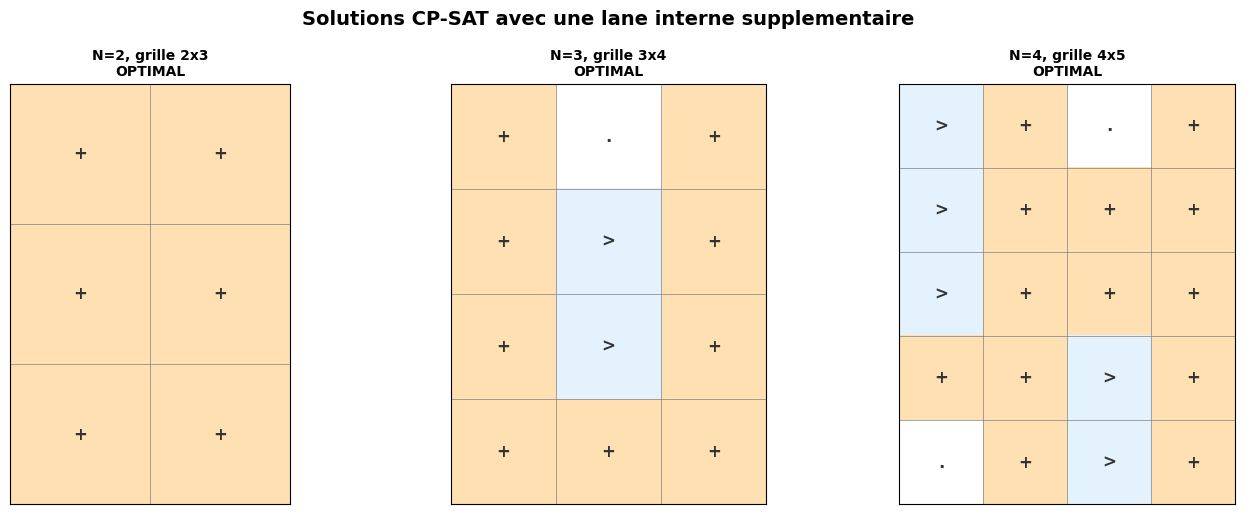

In [11]:
fig, axes = plt.subplots(1, len(CASES), figsize=(14, 5.2))

for ax, (W, H) in zip(axes, CASES):
    result = cpsat_results[(W, H)]
    grid = result['grid']
    if grid is not None:
        cmap = mcolors.ListedColormap(['#FFFFFF', '#E3F2FD', '#E3F2FD',
                                        '#E3F2FD', '#E3F2FD',
                                        '#FFE0B2', '#FFE0B2', '#FFE0B2', '#FFE0B2'])
        ax.imshow(grid, cmap=cmap, vmin=0, vmax=8, aspect='equal')
        for i in range(H):
            for j in range(W):
                ax.text(j, i, SYM[grid[i, j]], ha='center', va='center',
                        fontsize=12, fontweight='bold', color='#333')
        for i in range(H + 1):
            ax.axhline(i - 0.5, color='gray', linewidth=0.5)
        for j in range(W + 1):
            ax.axvline(j - 0.5, color='gray', linewidth=0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"N={W}, grille {W}x{H}\n{result['status']}",
                 fontsize=10, fontweight='bold')

plt.suptitle('Solutions CP-SAT avec une lane interne supplementaire',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

***

## 6. Comparaison MIP vs CP-SAT (~5 min)

### Discrimination attendue

Les deux moteurs resolvent le meme modele avec une capacite totale `P` par face. Le MIP represente `P/N` en continu ; CP-SAT utilise des unites entieres.

Quand `N` ne divise pas `P`, le mode `band` conserve exactement l'injection de chaque source en repartissant ses unites entre `floor(P/N)` et `ceil(P/N)`. Le mode `ceil` exige au moins `ceil(P/N)` sur chacune des `N` sorties : la somme demandee depasse alors l'injection exacte `P`. Cette impossibilite vient de la conservation globale de chaque source, pas d'une face de sortie particuliere.

### Pourquoi une ligne supplementaire ?

La capacite partagee rend les grilles carrees `N x N` infaisables sur les cas mesures : elles ne disposent pas d'une lane interne suffisante pour redistribuer simultanement toutes les commodites. Les experiences principales emploient donc `W=N, H=N+1`, avec toujours exactement `N` sources et `N` sorties.

### Avertissement d'honnetete

Un statut `FEASIBLE` n'est pas `OPTIMAL`, et un statut `UNKNOWN` n'est pas `INFEASIBLE`. La comparaison principale s'arrete aux cas pour lesquels les deux moteurs rendent une grille. Le cas `N=5` est affiche separement comme limite de temps experimentale.

In [12]:
print("Comparaison directe sur la meme capacite physique (P = 8)")
print("=" * 104)
print(f"{'N / grille':<13} {'MIP':<9} {'err MIP':<10} {'CP bande':<10} "
      f"{'err CP':<9} {'CP ceil':<11} {'obj MIP/CP':<12}")
print("-" * 104)

for W, H in CASES:
    n = W
    mip = mip_results_summary[(W, H)]
    cp = cpsat_results[(W, H)]
    ceil = cpsat_ceil_results[(W, H)]
    mip_error = (f"{mip['share_error']:.2e}"
                 if mip['share_error'] is not None else "N/A")
    cp_error = (f"{cp['share_error']:.4f}"
                if cp['share_error'] is not None else "N/A")
    objectives = (f"{mip['objective']:.0f}/{cp['objective']:.0f}"
                  if mip['objective'] is not None and cp['objective'] is not None
                  else "N/A")
    print(f"{n} / {W}x{H:<7} {mip['status']:<9} {mip_error:<10} "
          f"{cp['status']:<10} {cp_error:<9} {ceil['status']:<11} "
          f"{objectives:<12}")

print("=" * 104)
print("Lecture : N x N est infaisable avec une capacite partagee ; la grille")
print("N x (N+1) ajoute une lane interne sans ajouter de source ni de sortie.")
print("Pour N=3, le MIP livre P/N exactement ; CP-SAT repartit les 8 unites")
print("en {2, 3, 3}. Le mode ceil exige 9 unites au total par source alors")
print("que son injection vaut exactement 8 : l'infaisabilite vient de la")
print("conservation de l'injection, pas d'une face de sortie particuliere.")

Comparaison directe sur la meme capacite physique (P = 8)
N / grille    MIP       err MIP    CP bande   err CP    CP ceil     obj MIP/CP  
--------------------------------------------------------------------------------------------------------
2 / 2x3       OPTIMAL   0.00e+00   OPTIMAL    0.0000    OPTIMAL     6/6         
3 / 3x4       OPTIMAL   4.44e-16   OPTIMAL    0.6667    INFEASIBLE  11/11       
4 / 4x5       FEASIBLE  0.00e+00   OPTIMAL    0.0000    OPTIMAL     18/18       
Lecture : N x N est infaisable avec une capacite partagee ; la grille
N x (N+1) ajoute une lane interne sans ajouter de source ni de sortie.
Pour N=3, le MIP livre P/N exactement ; CP-SAT repartit les 8 unites
en {2, 3, 3}. Le mode ceil exige 9 unites au total par source alors
que son injection vaut exactement 8 : l'infaisabilite vient de la
conservation de l'injection, pas d'une face de sortie particuliere.


***

## 7. Deux verifications independantes (~6 min)

### 1. Audit du routage effectivement produit

`audit_solver_flow` ne resout rien. Il relit le tenseur retourne par le moteur et verifie : conservation par cellule et source, compatibilite des roles, egalite des faces partagees, injections, matrice de sortie et charge totale de chaque face. Il certifie donc le routage concret affiche par le solveur.

### 2. LP topologique reconstruit depuis la grille

`validate_balancer_topology` ignore le tenseur du solveur. Il reconstruit un nouveau programme lineaire multicommodite depuis les seuls composants de la grille, impose une capacite totale `P` par face et demande le partage continu ideal `P/N` pour toutes les sources simultanement.

Ces verdicts repondent a deux questions differentes :

- le solveur a-t-il effectivement produit un routage conforme a son domaine ?
- la topologie choisie peut-elle supporter le partage continu ideal avec les capacites physiques partagees ?

Pour CP-SAT en mode bande, une matrice entiere peut differer de `P/N` tout en etant conforme ; le LP topologique montre separement si la meme grille supporterait le partage continu ideal. Aucun max-flow source-par-source ni arc interne de capacite infinie n'est utilise.

In [13]:
def audit_solver_flow(result, tol=1e-7):
    """Audite le tenseur de flux retourne par un solveur, sans le resoudre."""
    grid = result['grid']
    tensor = result['flow_tensor']
    if grid is None or tensor is None:
        return {'valid': False, 'max_violation': None, 'max_face_load': None,
                'reached': 0, 'matrix': None}

    H, W = grid.shape
    N = min(H, W)
    P = result['P']
    violations = []

    def record(value):
        violations.append(max(0.0, float(value)))

    # Faces actives et capacite physique totale partagee.
    for i in range(H):
        for j in range(W):
            k = int(grid[i, j])
            used = (COMP_IN[k] | COMP_OUT[k]) if k else set()
            for d in range(4):
                load = float(tensor[i, j, d].sum())
                record(load - P)
                if d not in used:
                    record(load)
            if k:
                for s in range(N):
                    incoming = sum(tensor[i, j, d, s] for d in COMP_IN[k])
                    outgoing = sum(tensor[i, j, d, s] for d in COMP_OUT[k])
                    record(abs(incoming - outgoing))

    # Egalite des deux representations de chaque face interne et roles opposes.
    for i in range(H):
        for j in range(W - 1):
            record(np.abs(tensor[i, j, 2] - tensor[i, j + 1, 3]).max())
            if tensor[i, j, 2].sum() > tol:
                left, right = int(grid[i, j]), int(grid[i, j + 1])
                compatible = ((2 in COMP_OUT.get(left, set()) and
                               3 in COMP_IN.get(right, set())) or
                              (2 in COMP_IN.get(left, set()) and
                               3 in COMP_OUT.get(right, set())))
                record(0.0 if compatible else tensor[i, j, 2].sum())
    for i in range(H - 1):
        for j in range(W):
            record(np.abs(tensor[i, j, 1] - tensor[i + 1, j, 0]).max())
            if tensor[i, j, 1].sum() > tol:
                top, bottom = int(grid[i, j]), int(grid[i + 1, j])
                compatible = ((1 in COMP_OUT.get(top, set()) and
                               0 in COMP_IN.get(bottom, set())) or
                              (1 in COMP_IN.get(top, set()) and
                               0 in COMP_OUT.get(bottom, set())))
                record(0.0 if compatible else tensor[i, j, 1].sum())

    # Bords : injections exactes, N sorties, autres faces fermees.
    for j in range(W):
        record(np.abs(tensor[0, j, 0]).max())
        record(np.abs(tensor[H - 1, j, 1]).max())
    for i in range(H):
        expected = np.zeros(N)
        if i < N:
            expected[i] = P
        record(np.abs(tensor[i, 0, 3] - expected).max())
        if i >= N:
            record(np.abs(tensor[i, W - 1, 2]).max())

    matrix = np.array([[tensor[o, W - 1, 2, s] for o in range(N)]
                       for s in range(N)])
    record(np.abs(matrix - result['share_matrix']).max())
    for s in range(N):
        record(abs(matrix[s].sum() - P))
    if result['engine'] == 'MIP' or result.get('mode') == 'ceil':
        record(np.abs(matrix - result['share']).max())
    else:
        record(np.maximum(result['share_lo'] - matrix, 0).max())
        record(np.maximum(matrix - result['share_hi'], 0).max())

    max_violation = max(violations, default=0.0)
    max_face_load = float(tensor.sum(axis=3).max())
    return {'valid': max_violation <= tol, 'max_violation': max_violation,
            'max_face_load': max_face_load,
            'reached': int(np.sum(matrix > tol)), 'matrix': matrix}


def validate_balancer_topology(grid, n_sources, P=8, tol=1e-7):
    """Cherche un partage continu ideal par LP, depuis la grille seule."""
    H, W = grid.shape
    N = n_sources
    assert N == min(H, W)
    solver = pywraplp.Solver.CreateSolver('GLOP')
    flow = {(i, j, d, s): solver.NumVar(0.0, float(P), f'v_{i}_{j}_{d}_{s}')
            for i in range(H) for j in range(W) for d in range(4) for s in range(N)}

    # Semantique locale fixe et capacite partagee, toutes sources confondues.
    for i in range(H):
        for j in range(W):
            k = int(grid[i, j])
            used = (COMP_IN[k] | COMP_OUT[k]) if k else set()
            for d in range(4):
                if d not in used:
                    for s in range(N):
                        solver.Add(flow[i, j, d, s] == 0.0)
                solver.Add(sum(flow[i, j, d, s] for s in range(N)) <= P)
            if k:
                for s in range(N):
                    solver.Add(sum(flow[i, j, d, s] for d in COMP_IN[k]) ==
                               sum(flow[i, j, d, s] for d in COMP_OUT[k]))

    # Faces internes : meme valeur seulement si les roles sont complementaires.
    for i in range(H):
        for j in range(W - 1):
            left, right = int(grid[i, j]), int(grid[i, j + 1])
            compatible = ((2 in COMP_OUT.get(left, set()) and
                           3 in COMP_IN.get(right, set())) or
                          (2 in COMP_IN.get(left, set()) and
                           3 in COMP_OUT.get(right, set())))
            for s in range(N):
                solver.Add(flow[i, j, 2, s] == flow[i, j + 1, 3, s])
                if not compatible:
                    solver.Add(flow[i, j, 2, s] == 0.0)
    for i in range(H - 1):
        for j in range(W):
            top, bottom = int(grid[i, j]), int(grid[i + 1, j])
            compatible = ((1 in COMP_OUT.get(top, set()) and
                           0 in COMP_IN.get(bottom, set())) or
                          (1 in COMP_IN.get(top, set()) and
                           0 in COMP_OUT.get(bottom, set())))
            for s in range(N):
                solver.Add(flow[i, j, 1, s] == flow[i + 1, j, 0, s])
                if not compatible:
                    solver.Add(flow[i, j, 1, s] == 0.0)

    # Bords et demande ideale exacte P/N.
    share = P / N
    for j in range(W):
        for s in range(N):
            solver.Add(flow[0, j, 0, s] == 0.0)
            solver.Add(flow[H - 1, j, 1, s] == 0.0)
    for i in range(H):
        for s in range(N):
            solver.Add(flow[i, 0, 3, s] == (float(P) if i == s else 0.0))
            if i < N:
                solver.Add(flow[i, W - 1, 2, s] == share)
            else:
                solver.Add(flow[i, W - 1, 2, s] == 0.0)

    status = solver.Solve()
    status_name = {0: 'OPTIMAL', 2: 'INFEASIBLE', 4: 'ABNORMAL',
                   5: 'NOT_SOLVED'}.get(status, 'UNKNOWN')
    if status != pywraplp.Solver.OPTIMAL:
        return {'valid': False, 'status': status_name,
                'max_face_load': None, 'matrix': None}
    loads = [sum(flow[i, j, d, s].solution_value() for s in range(N))
             for i in range(H) for j in range(W) for d in range(4)]
    matrix = np.array([[flow[o, W - 1, 2, s].solution_value()
                        for o in range(N)] for s in range(N)])
    max_error = float(np.abs(matrix - share).max())
    return {'valid': max_error <= tol and max(loads) <= P + tol,
            'status': status_name, 'max_face_load': max(loads),
            'matrix': matrix}


print("Deux validateurs compiles : audit du flux produit + LP topologique independant.")

Deux validateurs compiles : audit du flux produit + LP topologique independant.


### Controles negatifs et validation des solutions obtenues

In [14]:
print("=" * 82)
print("Controles negatifs et validation independante")
print("=" * 82)

# Controle negatif 1 : lignes independantes, aucun brassage.
grid_all_belts = np.full((3, 2), 3, dtype=int)
v_belts = validate_balancer_topology(grid_all_belts, 2, P=P_FULL)
print(f"Tout belt-E 2x3 : topologie valide={v_belts['valid']}")

# Controle negatif 2 : ancien 2x2 accepte par les max-flows separes. Il route
# chaque source seule, mais surcharge une face quand elles sont simultanees.
grid_old_hand = np.array([[7, 5], [7, 5]], dtype=int)
v_old_hand = validate_balancer_topology(grid_old_hand, 2, P=P_FULL)
print(f"Ancienne grille 2x2 : topologie partagee valide={v_old_hand['valid']}")

validator_results = {}
for engine, results in (("MIP", mip_results_summary), ("CP-SAT", cpsat_results)):
    print(f"\n--- {engine} ---")
    for (W, H), result in sorted(results.items()):
        audit = audit_solver_flow(result)
        topology = validate_balancer_topology(result['grid'], W, P=P_FULL)
        validator_results[(engine, W, H)] = {
            'audit': audit,
            'topology': topology,
        }
        print(f"N={W}, {W}x{H} : flux={audit['valid']}, "
              f"LP={topology['valid']}, charge max={audit['max_face_load']:.3f}/{P_FULL}, "
              f"atteints={audit['reached']}/{W*W}")

control_p9_audit = audit_solver_flow(control_p9)
control_p9_topology = validate_balancer_topology(control_p9['grid'], 3, P=9)
print("\n--- Controle N=3, P=9 ---")
print(f"Flux={control_p9_audit['valid']}, LP={control_p9_topology['valid']}, "
      f"charge max={control_p9_audit['max_face_load']:.3f}/9")

print("\n--- Baseline au mixer isole ---")
baseline_val = validate_balancer_topology(baseline_mixer, 3, P=P_FULL)
print(f"Topologie valide={baseline_val['valid']} (aucun brassage vertical compatible)")
print("=" * 82)

Controles negatifs et validation independante
Tout belt-E 2x3 : topologie valide=False
Ancienne grille 2x2 : topologie partagee valide=False

--- MIP ---
N=2, 2x3 : flux=True, LP=True, charge max=8.000/8, atteints=4/4
N=3, 3x4 : flux=True, LP=True, charge max=8.000/8, atteints=9/9
N=4, 4x5 : flux=True, LP=True, charge max=8.000/8, atteints=16/16

--- CP-SAT ---
N=2, 2x3 : flux=True, LP=True, charge max=8.000/8, atteints=4/4
N=3, 3x4 : flux=True, LP=True, charge max=8.000/8, atteints=9/9
N=4, 4x5 : flux=True, LP=True, charge max=8.000/8, atteints=16/16

--- Controle N=3, P=9 ---
Flux=True, LP=True, charge max=9.000/9

--- Baseline au mixer isole ---
Topologie valide=False (aucun brassage vertical compatible)


### Durcissement : split equitable du mixer (contrainte C9)

La relaxation documentee en section 2 -- la repartition entre les deux sorties d'un mixer est un degre de liberte -- fait du modele une **borne superieure de faisabilite** : une topologie valide ici peut n'etre realisable par aucun splitter Factorio, qui partage son debit total en parts egales.

La contrainte C9 (`split_equitable=True` dans `solve_cpsat_balancer`) ferme ce degre de liberte en imposant `sortie1 == sortie2` sur chaque mixer pose. Deux mesures independantes suivent :

1. **Survie des solutions principales** : on relit le tenseur de flux deja produit par les 6 solutions principales (3 MIP + 3 CP-SAT bande) et on mesure l'ecart `|sortie1 - sortie2|` de chaque mixer. Une solution survit si tous ses mixers sont deja equilibres.
2. **Existence sous durcissement** : on re-resout les memes cas avec C9 active. Si le statut reste `OPTIMAL`/`FEASIBLE`, le cas reste faisable en cherchant une nouvelle topologie equitable ; un statut `INFEASIBLE` prouverait que la relaxation elargissait reellement l'espace de recherche.

Avec des flux entiers, C9 impose en sus un total PAIR par mixer -- une contrainte physique reelle des splitters discrets (les items ne se partagent pas), pas un artefact de modelisation.

In [15]:
def mixer_split_imbalance(result):
    """Ecart |sortie1 - sortie2| de chaque mixer, relu depuis le tenseur produit."""
    grid, tensor = result['grid'], result['flow_tensor']
    if grid is None or tensor is None:
        return {'per_mixer': {}, 'worst': None}
    H, W = grid.shape
    per_mixer = {}
    for i in range(H):
        for j in range(W):
            k = int(grid[i, j])
            if k in (5, 6, 7, 8):
                d1, d2 = sorted(COMP_OUT[k])
                per_mixer[(i, j)] = abs(float(tensor[i, j, d1].sum())
                                        - float(tensor[i, j, d2].sum()))
    return {'per_mixer': per_mixer,
            'worst': max(per_mixer.values(), default=0.0)}


print("Durcissement C9 - survie des 6 solutions principales (split equitable)")
print("=" * 84)
print(f"{'Engine':<8} {'N / grille':<12} {'Mixers':<8} {'Pire |s1-s2|':<14} {'Survit'}")
print("-" * 84)

split_measurements = {}
for engine, results in (("MIP", mip_results_summary), ("CP-SAT", cpsat_results)):
    for (W, H), result in sorted(results.items()):
        meas = mixer_split_imbalance(result)
        tol = 1e-6 if engine == "MIP" else 0.5
        survives = meas['worst'] is not None and meas['worst'] <= tol
        split_measurements[(engine, W, H)] = {**meas, 'survives': survives}
        worst = (f"{meas['worst']:.4f}" if meas['worst'] is not None else "N/A")
        print(f"{engine:<8} {W} / {W}x{H:<7} {len(meas['per_mixer']):<8} "
              f"{worst:<14} {survives}")
n_survivors = sum(1 for m in split_measurements.values() if m['survives'])
print("=" * 84)
print(f"Lecture : {n_survivors}/6 solutions principales survivent TELLES QUELLES")
print("au durcissement C9 (tous leurs mixers deja a parts egales).")

print("\nRe-resolution CP-SAT avec C9 actif (memes cas, meme bande, P = 8)")
print("=" * 84)
cpsat_eq_results = {}
for W, H in CASES:
    relaxed = cpsat_results[(W, H)]
    hardened = solve_cpsat_balancer(W, H, time_limit=15.0, P=P_FULL,
                                    mode='band', split_equitable=True)
    cpsat_eq_results[(W, H)] = hardened
    objs = (f"{relaxed['objective']:.0f} -> {hardened['objective']:.0f}"
            if hardened['objective'] is not None
            else f"{relaxed['objective']:.0f} -> (aucun)")
    print(f"N={W}, {W}x{H} : {relaxed['status']} -> {hardened['status']}, "
          f"objectif {objs}")
    if hardened['grid'] is not None:
        audit = audit_solver_flow(hardened)
        topology = validate_balancer_topology(hardened['grid'], W, P=P_FULL)
        meas = mixer_split_imbalance(hardened)
        print(f"  audit flux={audit['valid']}, LP topologique={topology['valid']}, "
              f"pire |s1-s2|={meas['worst']:.4f}")
print("=" * 84)

print("\nControle divisible durci : N=3, grille 3x4, P=9, ceil + C9")
control_p9_eq = solve_cpsat_balancer(3, 4, time_limit=15.0, P=9, mode='ceil',
                                     split_equitable=True)
err_p9_eq = (f"{control_p9_eq['share_error']:.4f}"
             if control_p9_eq['share_error'] is not None else "N/A")
print(f"  Statut={control_p9_eq['status']}, part={control_p9_eq['share']:.1f}, "
      f"erreur={err_p9_eq}")

Durcissement C9 - survie des 6 solutions principales (split equitable)
Engine   N / grille   Mixers   Pire |s1-s2|   Survit
------------------------------------------------------------------------------------
MIP      2 / 2x3       6        8.0000         False
MIP      3 / 3x4       10       8.0000         False
MIP      4 / 4x5       16       8.0000         False
CP-SAT   2 / 2x3       6        8.0000         False
CP-SAT   3 / 3x4       9        8.0000         False
CP-SAT   4 / 4x5       13       8.0000         False
Lecture : 0/6 solutions principales survivent TELLES QUELLES
au durcissement C9 (tous leurs mixers deja a parts egales).

Re-resolution CP-SAT avec C9 actif (memes cas, meme bande, P = 8)
N=2, 2x3 : OPTIMAL -> INFEASIBLE, objectif 6 -> (aucun)


N=3, 3x4 : OPTIMAL -> INFEASIBLE, objectif 11 -> (aucun)


N=4, 4x5 : OPTIMAL -> INFEASIBLE, objectif 18 -> (aucun)

Controle divisible durci : N=3, grille 3x4, P=9, ceil + C9
  Statut=INFEASIBLE, part=3.0, erreur=N/A


***
## 8. Verdict : capacite partagee et domaine numerique (~4 min)

### Question posee

Que montrent conjointement les statuts des solveurs, l'audit du flux concret et la faisabilite du partage continu ideal sur chaque grille obtenue ? Le tableau suivant est genere directement depuis ces mesures independantes.

### Resultat empirique observe

1. **La capacite est physique et partagee.** Chaque face transporte au total au plus `P`, et non `P` pour chacune des `N` sources.
2. **La ligne interne est necessaire sur les cas testes.** Les grilles `N x N` sont prouvees infaisables pour `N=2`, `N=3` et `N=4`; les grilles `N x (N+1)` fournissent une lane de redistribution sans ajouter d'entree ni de sortie.
3. **Le discriminant entier reste visible.** Pour `N=3, P=8`, CP-SAT bande conserve les huit unites avec des parts 2 ou 3, tandis que le MIP continu realise `8/3`. Le mode ceil est infaisable car `3 * ceil(8/3) > 8` pour chaque injection.
4. **Le controle divisible est reellement valide.** Le cas `N=3, P=9` passe l'audit du flux produit et le LP topologique.
5. **Les statuts restent honnetes.** Une solution `FEASIBLE` est exploitable mais son objectif n'est pas certifie optimal ; `UNKNOWN` n'autorise aucune conclusion de faisabilite.
6. **La relaxation du mixer est une borne superieure, et elle est ici necessaire.** Mesure C9 (section 7) : dans les 6 solutions principales, chaque mixer est un pass-through pur (pire `|sortie1 - sortie2| = P = 8` -- la repartition libre sert a tout devier vers une seule sortie), donc 0/6 survivent au durcissement. Re-resolues avec split equitable, les trois grilles `N x (N+1)` deviennent `INFEASIBLE` -- statut prouve, pas `UNKNOWN` -- y compris le cas divisible `N=2` ou chaque livraison vaut exactement `P/N = 4`. La cause est structurelle : tout composant admettant une entree N a aussi la sortie S parmi ses sorties (belt-S, mixer-SE, mixer-SW), or la face S est fermee sur la rangee du bas -- un mixer equitable qui y recoit du flux du nord devrait emettre autant au sud (zero force). La lane interne ne peut donc rien transporter sous C9, et la grille retombe sur le cas carre infaisable. Les solutions du modele relaxe ne sont pas "presque" realisables : la relaxation est la seule raison de leur existence, ce qui en fait un objet d'etude a part entiere.

In [16]:
print("Tableau recapitulatif du verdict (P = 8)")
print("=" * 116)
print(f"{'N / grille':<13} {'MIP':<9} {'CP bande':<10} {'CP ceil':<11} "
      f"{'flux MIP':<10} {'LP MIP':<8} {'flux CP':<9} {'LP CP':<7} "
      f"{'charge max':<11}")
print("-" * 116)

for W, H in CASES:
    mip = mip_results_summary[(W, H)]
    cp = cpsat_results[(W, H)]
    ceil = cpsat_ceil_results[(W, H)]
    vm = validator_results[('MIP', W, H)]
    vc = validator_results[('CP-SAT', W, H)]
    max_load = max(vm['audit']['max_face_load'], vc['audit']['max_face_load'])
    print(f"{W} / {W}x{H:<7} {mip['status']:<9} {cp['status']:<10} "
          f"{ceil['status']:<11} {str(vm['audit']['valid']):<10} "
          f"{str(vm['topology']['valid']):<8} {str(vc['audit']['valid']):<9} "
          f"{str(vc['topology']['valid']):<7} {max_load:.3f}/{P_FULL}")

print("=" * 116)
print(f"Controle N=3, P=9 : statut={control_p9['status']}, "
      f"flux={control_p9_audit['valid']}, LP={control_p9_topology['valid']}")
print(f"Limite N=5, grille 5x6 : CP-SAT bande={limit_n5['status']} "
      f"(pas de comparaison MIP revendiquee)")

Tableau recapitulatif du verdict (P = 8)
N / grille    MIP       CP bande   CP ceil     flux MIP   LP MIP   flux CP   LP CP   charge max 
--------------------------------------------------------------------------------------------------------------------
2 / 2x3       OPTIMAL   OPTIMAL    OPTIMAL     True       True     True      True    8.000/8
3 / 3x4       OPTIMAL   OPTIMAL    INFEASIBLE  True       True     True      True    8.000/8
4 / 4x5       FEASIBLE  OPTIMAL    OPTIMAL     True       True     True      True    8.000/8
Controle N=3, P=9 : statut=OPTIMAL, flux=True, LP=True
Limite N=5, grille 5x6 : CP-SAT bande=FEASIBLE (pas de comparaison MIP revendiquee)


***
## 9. Sources et references (~2 min)

### Source canonique

- **Venturini, G. (2024-12-27). *Learning Solver Design: Automating Factorio Balancers***. Article de blog personnel.
  - Archive : `G:\Mon Drive\MyIA\IA\Bibliographie IA\Constraint Programming\2024 - Venturini - Learning Solver Design - Automating Factorio Balancers.pdf`
  - Pas de licence declaree : reimplementation originale ci-dessus.
  - Attribution : grille de cellules, conservation locale et objectif de balance.
  - Divergence : mixer redistributif a une cellule au lieu du splitter a deux cellules.

- **Google OR-Tools** : modules `ortools.linear_solver` (SCIP et GLOP) et `ortools.sat.python.cp_model`.

### Limites du notebook

- Les experiences principales couvrent `N=2`, `N=3` et `N=4` sur des grilles `W=N, H=N+1`.
- Le cas `N=5` illustre seulement une limite de temps : aucun verdict MIP comparatif n'est revendique.
- Le mixer relaxe la semantique du splitter Factorio : la repartition entre ses sorties est libre, ce qui fait du modele une borne superieure de faisabilite. Le durcissement C9 (section 7) mesure l'ecart : 0/6 solutions principales survivent au split equitable, et les trois cas principaux deviennent `INFEASIBLE` -- la relaxation n'est donc pas un angle mort, elle est quantifiee.
- Les underground belts restent hors perimetre.
- CP-SAT est deterministe ici (`num_workers=1`, graine fixe) ; SCIP n'offre pas la meme reproductibilite bit-a-bit.

### Exercice 1 : ajouter un underground belt dans le modele

Reprenez `solve_cpsat_balancer` et ajoutez un type de composant `underground belt` qui permet de transporter le flux sur 2 cellules alignees (sans obstacle entre les deux).

**Indice** : il faut une nouvelle dimension dans `comp` (la distance), et une variable binaire pour indiquer que la cellule contient l'entree ou la sortie du tunnel.

In [17]:
# Exercice 1 : etendre avec underground belts (skeleton)

def solve_cpsat_balancer_with_underground(width, height, time_limit=30.0):
    """Version etendue avec underground belts."""
    # TODO etudiant : implementer la version avec underground belts
    # Indice : ajouter 4 types d'underground (N, S, E, W) avec distance 2
    # Chaque underground couple 2 cellules alignees
    pass  # TODO etudiant
    return None

print("Exercice 1 : skeleton defini.")


Exercice 1 : skeleton defini.


### Exercice 2 : etude de la divisibilite P mod N

Faites varier `P` dans `solve_cpsat_balancer(3, 4, P=p, mode='ceil')` pour `p` dans `[6, 8, 9, 10, 12]`.

**Question** : le mode ceil est-il faisable exactement lorsque `3` divise `P` ? Reliez votre observation a la conservation de l'injection totale de chaque source.

In [18]:
# Exercice 2 : etude de la divisibilite P mod N sur une grille 3x4
# TODO etudiant : appeler solve_cpsat_balancer(3, 4, P=p, mode='ceil')
# pour p dans [6, 8, 9, 10, 12] et relever statut et share_error
# Indice : comparer p % 3 avec la somme demandee 3 * ceil(p / 3)
result = None  # TODO etudiant : dictionnaire {p: (statut, share_error)}
print("Exercice a completer : divisibilite P mod N en mode ceil.")

Exercice a completer : divisibilite P mod N en mode ceil.


### Exercice 3 : trouver la hauteur minimale

Pour `N` fixe, testez les grilles `W=N, H=N`, puis `H=N+1`, puis des hauteurs plus grandes si necessaire. Une largeur est eliminee comme minimale seulement si toutes les hauteurs precedentes ont un statut `INFEASIBLE`; `UNKNOWN` ne suffit pas.

**Question** : la premiere hauteur faisable est-elle toujours `N+1` pour `N` dans `[2, 3, 4, 5]` ? Comparez aussi la charge maximale retournee par `audit_solver_flow`.

In [19]:
# Exercice 3 : hauteur minimale avec capacite partagee

def find_minimum_height(n_sources, P=8, max_extra_rows=3):
    """Cherche la premiere hauteur prouvee faisable sans sauter un UNKNOWN."""
    # TODO etudiant : tester H de n_sources a n_sources + max_extra_rows
    # Indice : retourner None si un statut UNKNOWN empeche de prouver la minimalite
    pass  # TODO etudiant
    return None


print("Exercice 3 : skeleton defini pour la recherche de hauteur minimale.")

Exercice 3 : skeleton defini pour la recherche de hauteur minimale.


***

## Recapitulatif

### Ce qu'il faut retenir

1. **Capacite partagee** : une face physique transporte au total au plus `P`, toutes sources confondues.
2. **Debit atteint** : chaque source injecte exactement `P` et livre `P/N` a chaque sortie en MIP continu ; CP-SAT bande conserve `P` avec des parts entieres voisines de `P/N`.
3. **Deux preuves distinctes** : l'audit controle le tenseur concret du solveur ; le LP multicommodite reconstruit certifie la capacite topologique de la grille pour le partage continu ideal.
4. **Topologie non triviale** : les cas carres testes sont infaisables avec la capacite physique ; une ligne interne supplementaire permet le routage sans ajouter de source ni de sortie.
5. **Verdicts honnetes** : `FEASIBLE` ne certifie pas l'objectif optimal et `UNKNOWN` ne prouve aucune impossibilite.
6. **Discrimination numerique** : lorsque `N` ne divise pas `P`, le MIP represente la part exacte, tandis que CP-SAT doit distribuer des entiers. Le controle divisible montre que cet ecart vient du domaine, pas d'une inferiorite du solveur.
7. **Perimetre** : formulation originale inspiree de Venturini, mixer redistributif conservatif, sans underground belts.